***
# <font color=green size=10>**1ª ENTREGA DO PROJETO DATA SCIENCE APLICADO À SAÚDE**</font>
***

**>> Nome completo dos integrantes da equipe**
- Fernando Souza Rodrigues
- Kelvin Araújo Ferreira


**>> Tema do projeto**

*Análise do dados nutricionais em comunidades rurais e urbanas em Roraima Durante a pândemia de Covid-19.*

*Quais foram as diferenças nos índices nutricionais (como IMC) entre comunidades rurais e urbanas em Roraima durante a pandemia? Isso pode ajudar a identificar desigualdades nutricionais para embasar políticas públicas de saúde.*


**>> Banco de dados consultado**

*Sistema de Vigilância Alimentar e Nutricional (SISVAN). [link do banco de dados](https://basedosdados.org/dataset/d0b61e1c-2ff2-43e7-b32f-5a054ba9b688?table=6e763e07-9b83-487e-9135-fca7872b1f16).*


**>> Banco de dados utilizado**

[link do banco de dados pré-processoado](https://drive.google.com/file/d/1-8FE24TE5t1PBCqHtFTn85_7CurTvq2z/view?usp=sharing)

## <font color=green size=6>**Desenvolvimento do projeto**</font>

**>> Problema a ser solucionado**

*Pretendemos estudar os dados de IMC dos municípios de Roraima...*

### **01. Importação de bibliotecas necessárias para o projeto.**

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly
from google.colab import drive

### **02. Importação do banco de dados original.**

In [12]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
df = pd.read_csv('/content/dataset_final.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135000 entries, 0 to 134999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ano            135000 non-null  int64  
 1   sigla_uf       135000 non-null  object 
 2   sigla_uf_nome  135000 non-null  object 
 3   idade          135000 non-null  int64  
 4   sexo           135000 non-null  object 
 5   raca_cor       135000 non-null  object 
 6   escolaridade   135000 non-null  object 
 7   peso           135000 non-null  float64
 8   altura         135000 non-null  float64
 9   imc            135000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 10.3+ MB


### **03. Pré-processamento dos dados para produzir o banco de dados para análise exploratória.**

####Traduzindo os códigos de município de Roraima

In [10]:
# Recomendamos que a equipe divida em várias células de código cada etapa do
# processamento e que utilize comentários para descrever cada etapa.
# Tabela com os códigos e nomes dos municípios de Roraima
tabela_roraima = pd.DataFrame({
    "CODIGO_IBGE": [
        140002, #1400027 - Amajari
        140005, #1400050 - Alto Alegre
        140010, #1400100 - Boa Vista
        140045, #1400456 - Pacaraima
        140015, #1400159 - Bonfim
        140017, #1400175 - Cantá
        140040, #1400407 - Normandia
        140070, #1400704 - Uiramutã
        140020, #1400209 - Caracaraí
        140028, #1400282 - Iracema
        140030, #1400308 - Mucajaí
        140023, #1400233 - Caroebe
        140047, #1400472 - Rorainópolis
        140050, #140050 - São João da Baliza
        140060 #1400605 - São Luiz
    ],
    "MUNICIPIO": [
        "Amajari", "Alto Alegre", "Boa Vista", "Pacaraima", "Bonfim", "Cantá", "Normandia",
        "Uiramutã", "Caracaraí", "Iracema", "Mucajaí", "Caroebe", "Rorainópolis",
        "São João da Baliza", "São Luiz"
    ]
})

# Criar um dicionário para mapear os códigos aos nomes dos municípios
mapeamento = dict(zip(tabela_roraima["CODIGO_IBGE"], tabela_roraima["MUNICIPIO"]))

# Criar a nova coluna com os nomes dos municípios usando o mapeamento
df["nome_municipio"] = df["id_municipio"].map(mapeamento)

# Exibir o DataFrame atualizado
df.sample(5)

,ano,mes,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,acompanhamento,id_individuo,idade,sexo,...,estado_nutricional_peso_idade_crianca,estado_nutricional_peso_altura_crianca,estado_nutricional_altura_idade_crianca,estado_nutricional_imc_idade_crianca,estado_nutricional_altura_idade_adolescente,estado_nutricional_imc_idade_adolescente,estado_nutricional_adulto,estado_nutricional_idoso,estado_nutricional_gestantes,nome_municipio
9480,2018,12,AL,Alagoas,270430,NaN,1BF8873365D8AEAC1BCCCB07CFAA7AF1CD387E9E,A9FE5D2272932E53688DB28987A7E082F54C655A,28,F,...,NaN,NaN,NaN,NaN,NaN,NaN,Adequado ou eutrófico,NaN,NaN,NaN
8303,2018,6,SC,Santa Catarina,420750,NaN,4CDEDABE0F09BEF382C4381B58AAC8FC4A3BE02C,1A3E0CA6563C2069C8C1D5FE901A3DF24AC5504A,1,M,...,Peso adequado para idade,Peso Adequado ou Eutrofico,Estatura adequada para a idade,Eutrofia,NaN,NaN,NaN,NaN,NaN,NaN
5486,2015,9,MT,Mato Grosso,510140,NaN,1CF9F124268BDEDFAD062C186DA6CAA453C8F59E,A77DF258FBEB7BF0C81382617E35BE562AE340B5,39,F,...,NaN,NaN,NaN,NaN,NaN,NaN,Sobrepeso,NaN,Sobrepeso,NaN
4627,2018,4,AM,Amazonas,130080,NaN,C590073322162224A980C6B4C21323088836BCE9,4466C023B20E6E57C185F3F98D508B2103D3DC31,11,M,...,NaN,NaN,NaN,NaN,Estatura adequada para a idade,Eutrofia,NaN,NaN,NaN,NaN
5217,2015,9,MT,Mato Grosso,510650,NaN,628428D2F87807EFAC87E5A1BFDA2182545FC82D,D3015B42143A43904C578C3049DB089AB7383BA1,36,F,...,NaN,NaN,NaN,NaN,NaN,NaN,Obesidade Grau I,NaN,NaN,NaN


####Removendo colunas

In [23]:
# Removendo temporáriamente as colunas relacionadas aos municipios so pra ter de onde começar o começo.
# Depois voltar fazendo os filtros dos outros municipios
del df['id_municipio']
del df['id_municipio_nome']
# -----------------------------------
del df['acompanhamento']
del df['povo_comunidade']
del df['id_individuo']
del df['data_acompanhamento']
del df['estado_nutricional_peso_idade_crianca']
del df['estado_nutricional_peso_altura_crianca']
del df['estado_nutricional_altura_idade_crianca']
del df['estado_nutricional_imc_idade_crianca']
del df['estado_nutricional_altura_idade_adolescente']
del df['estado_nutricional_imc_idade_adolescente']
del df['estado_nutricional_adulto']
del df['estado_nutricional_idoso']
del df['estado_nutricional_gestantes']
del df['imc_gestacional']
df

,ano,mes,sigla_uf,sigla_uf_nome,idade,sexo,raca_cor,escolaridade,peso,altura,imc
0,2013,8,AP,Amapá,30,F,Parda,Ensino fundamental 5ª a 8ª séries,75.7,1.65,27.81
1,2013,8,AP,Amapá,2,F,Parda,Creche,9.2,75.00,16.36
2,2013,8,AP,Amapá,3,M,Parda,Nenhum,15.6,100.00,15.60
3,2013,8,AP,Amapá,3,F,Branca,Creche,13.9,88.00,17.95
4,2013,8,AP,Amapá,4,M,Branca,Ensino fundamental 5ª a 8ª séries,19.1,105.00,17.32
...,...,...,...,...,...,...,...,...,...,...,...
9995,2014,10,GO,Goiás,3,F,Parda,Sem informação,12.4,90.00,15.31
9996,2014,10,GO,Goiás,5,M,Branca,Creche,18.7,115.00,14.14
9997,2014,10,GO,Goiás,5,F,Parda,Pré-escola (exceto ca),18.2,112.00,14.51
9998,2014,10,GO,Goiás,6,M,Branca,Pré-escola (exceto ca),21.1,114.00,16.24


####Contagem de valores de cada ano

In [51]:
contagem_escolaridade = df['escolaridade'].value_counts()

print(contagem_escolaridade)

escolaridade
Creche                                                            39193
Classe alfabetizada - ca                                          25810
Ensino fundamental 1ª a 4ª séries                                 18834
Ensino fundamental 5ª a 8ª séries                                 14684
Pré-escola (exceto ca)                                            12002
Ensino fundamental completo                                       11073
Ensino médio, médio2º ciclo (científico,técnico e etc)             7552
Superior, aperfeiçoamento, especialização, mestrado, doutorado     1513
Ensino fundamental eja - séries iniciais (supletivo 1ª a 4ª)       1182
Ensino médio especial                                               967
Ensino fundamental especial                                         869
Ensino fundamental eja - séries iniciais (supletivo 5ª a 8ª)        742
Ensino médio eja(supletivo)                                         383
Alfabetização para adultos (mobral, etc)           

In [52]:
contagem_raca = df['raca_cor'].value_counts()

print(contagem_raca)

raca_cor
Parda       75421
Branca      43907
Preta        7341
Amarela      5735
Indigena     2596
Name: count, dtype: int64


In [50]:
contagem_ano = df['ano'].value_counts()
contagem_uf = df['sigla_uf'].value_counts()

print(contagem_ano)
print("--------------------------")
print(contagem_uf)

ano
2012    13722
2013    12089
2011    11867
2009    10914
2014    10622
2010     9753
2015     9645
2016     7504
2019     7230
2018     7061
2017     6841
2023     6541
2022     6366
2008     6032
2021     4830
2020     3983
Name: count, dtype: int64
--------------------------
sigla_uf
RR    5000
RJ    5000
SP    5000
MG    5000
PA    5000
MS    5000
SC    5000
BA    5000
RS    5000
CE    5000
MT    5000
MA    5000
ES    5000
PB    5000
RO    5000
GO    5000
AL    5000
TO    5000
PE    5000
AM    5000
AC    5000
RN    5000
PI    5000
AP    5000
DF    5000
SE    5000
PR    5000
Name: count, dtype: int64


####Exploração Inicial dos Dados Analise o conteúdo do DataFrame para entender os dados disponíveis:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ano              10000 non-null  int64  
 1   mes              10000 non-null  int64  
 2   sigla_uf         10000 non-null  object 
 3   sigla_uf_nome    10000 non-null  object 
 4   idade            10000 non-null  int64  
 5   sexo             10000 non-null  object 
 6   raca_cor         10000 non-null  object 
 7   escolaridade     10000 non-null  object 
 8   peso             10000 non-null  float64
 9   altura           10000 non-null  float64
 10  imc              10000 non-null  float64
 11  imc_gestacional  271 non-null    float64
dtypes: float64(4), int64(3), object(5)
memory usage: 937.6+ KB


In [ ]:
df.describe()

,ano,mes,idade,peso,altura,imc,imc_gestacional
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,271.000000
mean,2016.338900,7.983600,21.701100,45.582863,91.219256,22.578578,23.167269
std,2.439558,3.022821,20.167013,26.878470,62.315685,13.878457,5.624844
min,2011.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014.000000,6.000000,4.000000,18.000000,1.710000,16.500000,20.320000
50%,2017.000000,9.000000,16.000000,49.600000,104.000000,20.810000,22.660000
75%,2018.000000,10.000000,34.000000,66.000000,151.000000,26.020000,25.825000
max,2022.000000,12.000000,102.000000,205.000000,245.000000,660.160000,38.670000


####Tratar Dados Faltantes ou Inconsistentes - Verificando se há valores ausentes e trate-os adequadamente:

In [53]:
# Verificar valores nulos
print(df.isnull().sum())

# Tratar valores nulos na coluna 'imc', por exemplo, preenchendo com a mediana
df['imc'] = df['imc'].fillna(df['imc'].median())


ano              0
sigla_uf         0
sigla_uf_nome    0
idade            0
sexo             0
raca_cor         0
escolaridade     0
peso             0
altura           0
imc              0
dtype: int64


In [54]:
# Verificar valores nulos
print(df.isnull().sum())

# Tratar valores nulos na coluna 'imc', por exemplo, preenchendo com a mediana
df['imc'] = df['imc'].fillna(df['imc'].median())

ano              0
sigla_uf         0
sigla_uf_nome    0
idade            0
sexo             0
raca_cor         0
escolaridade     0
peso             0
altura           0
imc              0
dtype: int64


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135000 entries, 0 to 134999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ano            135000 non-null  int64  
 1   sigla_uf       135000 non-null  object 
 2   sigla_uf_nome  135000 non-null  object 
 3   idade          135000 non-null  int64  
 4   sexo           135000 non-null  object 
 5   raca_cor       135000 non-null  object 
 6   escolaridade   135000 non-null  object 
 7   peso           135000 non-null  float64
 8   altura         135000 non-null  float64
 9   imc            135000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 10.3+ MB


In [56]:
df['ano'].unique()

array([2013, 2012, 2010, 2023, 2015, 2017, 2009, 2008, 2021, 2019, 2020,
       2014, 2022, 2016, 2018, 2011])

In [57]:
contagem_uf = df["sigla_uf"].value_counts()
print(contagem_uf)

sigla_uf
RR    5000
RJ    5000
SP    5000
MG    5000
PA    5000
MS    5000
SC    5000
BA    5000
RS    5000
CE    5000
MT    5000
MA    5000
ES    5000
PB    5000
RO    5000
GO    5000
AL    5000
TO    5000
PE    5000
AM    5000
AC    5000
RN    5000
PI    5000
AP    5000
DF    5000
SE    5000
PR    5000
Name: count, dtype: int64


In [58]:
contagem_estados = df["sigla_uf_nome"].value_counts()

print(contagem_estados)

sigla_uf_nome
Roraima                5000
Rio de Janeiro         5000
São Paulo              5000
Minas Gerais           5000
Pará                   5000
Mato Grosso do Sul     5000
Santa Catarina         5000
Bahia                  5000
Rio Grande do Sul      5000
Ceará                  5000
Mato Grosso            5000
Maranhão               5000
Espírito Santo         5000
Paraíba                5000
Rondônia               5000
Goiás                  5000
Alagoas                5000
Tocantins              5000
Pernambuco             5000
Amazonas               5000
Acre                   5000
Rio Grande do Norte    5000
Piauí                  5000
Amapá                  5000
Distrito Federal       5000
Sergipe                5000
Paraná                 5000
Name: count, dtype: int64


### **04. Análise Exploratória de Dados.**

In [59]:
# Filtrar o DataFrame para o período da pandemia (2018-2023)
df_pandemia = df[(df['ano'] >= 2018) & (df['ano'] <= 2023)]

# Calcular a média e o desvio padrão do IMC para cada estado
analise_imc_estados = df_pandemia.groupby('sigla_uf_nome')['imc'].agg(['mean', 'std']).reset_index()

# Renomear as colunas para melhor compreensão
analise_imc_estados.rename(columns={'mean': 'Media_IMC', 'std': 'Desvio_Padrao_IMC'}, inplace=True)

# Exibir os resultados
print("Média e Desvio Padrão do IMC por Estado:")
print(analise_imc_estados)

# Plotar o boxplot do IMC por estado
import plotly.express as px
fig = px.box(df_pandemia, x="sigla_uf_nome", y="imc", color="sigla_uf_nome", labels={"sigla_uf_nome": "Estado", "imc": "IMC"})
fig.update_layout(title="Boxplot do IMC por Estado")
fig.show()


Média e Desvio Padrão do IMC por Estado:
          sigla_uf_nome  Media_IMC  Desvio_Padrao_IMC
0                  Acre  22.438685           5.688746
1               Alagoas  22.215221           6.684482
2                 Amapá  26.188360           7.008238
3              Amazonas  22.012266           6.381561
4                 Bahia  22.783560           6.686809
5                 Ceará  21.857671           6.844765
6      Distrito Federal  25.689329           7.296806
7        Espírito Santo  22.212231           7.067874
8                 Goiás  22.842929           7.089256
9              Maranhão  23.678627           6.347956
10          Mato Grosso  24.269960           7.314773
11   Mato Grosso do Sul  23.938938           7.572490
12         Minas Gerais  24.580877           6.586454
13               Paraná  22.722399           7.363391
14              Paraíba  21.832227           6.622324
15                 Pará  24.007460           6.506115
16           Pernambuco  21.534824       

In [60]:
# @title Determinar a frequência relativa de mulheres e homens em cada estado.

# Frequência total de mulheres e homens em cada estado
proportion = df.groupby(["sigla_uf_nome", "sexo"]).size().reset_index(name="count")

# Criar o gráfico de barras
fig = px.bar(
    proportion,
    x="sigla_uf_nome",  # Mudança para estado
    y="count",
    color="sexo",
    text="count",
    title="Proporção de Mulheres e Homens por Estado",  # Título atualizado
    labels={"count": "Quantidade", "sigla_uf_nome": "Estado", "sexo": "Sexo"},  # Labels atualizados
    barmode="group"  # Barras lado a lado
)

# Configuração do gráfico
fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Estado",  # Eixo X atualizado
    yaxis_title="Quantidade",
    legend_title="Sexo"
)

# Exibir o gráfico
fig.show()


In [61]:
# @title Calcular a correlação entre idade e IMC dos homens e mulheres em cada estado.

# Correlação entre idade e IMC por estado
fig = px.scatter(
    df,
    x="idade",
    y="imc",
    color="sexo",  # Diferenciar por sexo
    title="Correlação entre Idade e IMC por Estado",  # Título atualizado
    labels={"idade": "Idade", "imc": "IMC", "sexo": "Sexo"},
    hover_data=["sigla_uf_nome"]  # Adicionar estado como dado de hover
)

fig.update_traces(marker=dict(size=10, opacity=0.8))  # Ajustar o tamanho e a opacidade dos pontos
fig.update_layout(
    xaxis_title="Idade",
    yaxis_title="IMC",
    legend_title="Sexo"
)

fig.show()


Output hidden; open in https://colab.research.google.com to view.

In [62]:
# @title Dividir os participantes em categorias etárias e calcular o IMC médio por faixa.

# Definir faixas etárias com limites claros
bins = [0, 18, 25, 40, 60, float('inf')]  # Faixas etárias
labels = ["0-18", "19-25", "26-40", "41-60", ">60"]

# Atribuir cada participante a uma faixa etária
df["faixa_etaria"] = pd.cut(df["idade"], bins=bins, labels=labels, right=False)

# Calcular o IMC médio por faixa etária
imc_por_faixa = df.groupby("faixa_etaria")["imc"].mean().reset_index()

# Criar o gráfico de barras
fig = px.bar(
    imc_por_faixa,
    x="faixa_etaria",
    y="imc",
    title="IMC Médio por Faixa Etária",
    labels={"faixa_etaria": "Faixa Etária", "imc": "IMC Médio"},
    text="imc"  # Exibir os valores no topo das barras
)

# Ajustar o texto e a aparência das barras
fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")  # Formatando o texto com 2 casas decimais
fig.update_layout(
    xaxis_title="Faixa Etária",
    yaxis_title="IMC Médio",
    showlegend=False  # Remover a legenda (não necessária)
)

fig.show()


<ipython-input-62-82556d2690f9>:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [63]:
# @title Dividir os participantes em categorias etárias e calcular o IMC médio por faixa.

# Criar categorias etárias
bins = [0, 18, 25, 40, 60, float('inf')]  # Faixas etárias
labels = ["0-18", "19-25", "26-40", "41-60", ">60"]
df["faixa_etaria"] = pd.cut(df["idade"], bins=bins, labels=labels, right=False)

# Calcular o IMC médio por faixa etária
imc_por_faixa = df.groupby("faixa_etaria")["imc"].mean().reset_index()

fig = px.bar(
    imc_por_faixa,
    x="faixa_etaria",
    y="imc",
    title="IMC Médio por Faixa Etária",
    labels={"faixa_etaria": "Faixa Etária", "imc": "IMC Médio"},
    text="imc"  # Exibir os valores no topo das barras
)

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")  # Formatar texto com 2 casas decimais
fig.update_layout(
    xaxis_title="Faixa Etária",
    yaxis_title="IMC Médio",
    showlegend=False  # Remover a legenda (não é necessária para este gráfico)
)

fig.show()

<ipython-input-63-b0d0157aaed7>:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [64]:
df.head()

,ano,sigla_uf,sigla_uf_nome,idade,sexo,raca_cor,escolaridade,peso,altura,imc,faixa_etaria
0,2013,RR,Roraima,71,F,Parda,Classe alfabetizada - ca,64.5,1.54,27.20,>60
1,2012,RR,Roraima,63,F,Parda,Classe alfabetizada - ca,91.0,1.57,36.92,>60
2,2012,RR,Roraima,67,F,Parda,Creche,54.0,1.46,25.33,>60
3,2010,RR,Roraima,60,F,Parda,Classe alfabetizada - ca,51.0,1.48,23.28,>60
4,2012,RR,Roraima,63,M,Parda,Creche,72.0,1.52,31.16,>60


<Axes: xlabel='idade'>

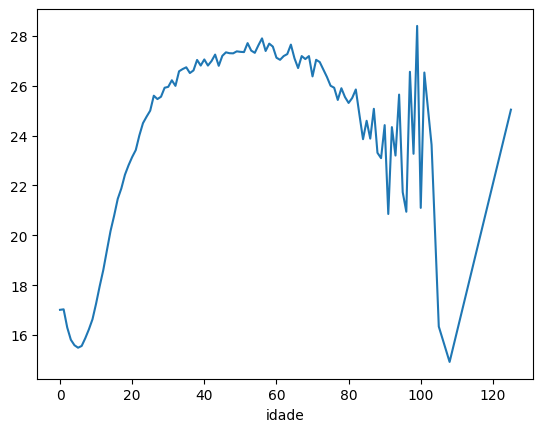

In [65]:
df.groupby("idade")["imc"].median().plot()

In [66]:
# Calculate the correlation matrix for numerical variables
df_num = df.select_dtypes(include=['float64', 'int64'])


# Display the correlation matrix
print(df_num)

         ano  idade  peso  altura    imc
0       2013     71  64.5    1.54  27.20
1       2012     63  91.0    1.57  36.92
2       2012     67  54.0    1.46  25.33
3       2010     60  51.0    1.48  23.28
4       2012     63  72.0    1.52  31.16
...      ...    ...   ...     ...    ...
134995  2009     53  76.4    1.56  31.39
134996  2023     53  84.9  162.00  32.35
134997  2021     53  68.0  164.00  25.28
134998  2015     53  73.0    1.53  31.18
134999  2020     53  68.2  162.00  25.99

[135000 rows x 5 columns]


In [67]:
df.head()

,ano,sigla_uf,sigla_uf_nome,idade,sexo,raca_cor,escolaridade,peso,altura,imc,faixa_etaria
0,2013,RR,Roraima,71,F,Parda,Classe alfabetizada - ca,64.5,1.54,27.20,>60
1,2012,RR,Roraima,63,F,Parda,Classe alfabetizada - ca,91.0,1.57,36.92,>60
2,2012,RR,Roraima,67,F,Parda,Creche,54.0,1.46,25.33,>60
3,2010,RR,Roraima,60,F,Parda,Classe alfabetizada - ca,51.0,1.48,23.28,>60
4,2012,RR,Roraima,63,M,Parda,Creche,72.0,1.52,31.16,>60


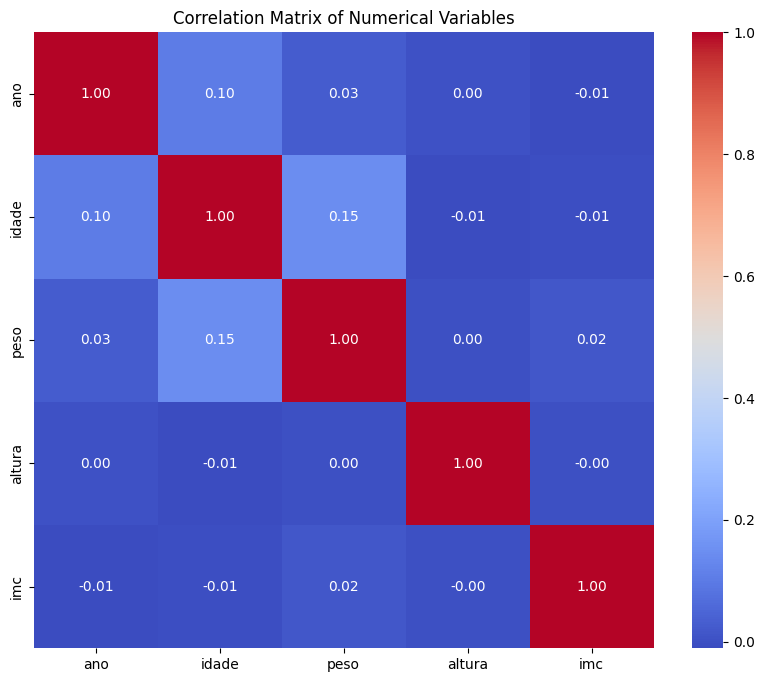

In [68]:
# Create a heatmap of the correlation matrix
correlation_matrix = df_num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [69]:
# @title correlação com vairáveis categóricas

# Selecionar apenas as variáveis categóricas
df_cat = df.select_dtypes(include=['object', 'category'])

# Inicializar uma matriz de correlação vazia
corr_matrix = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

In [70]:
pip install association-metrics


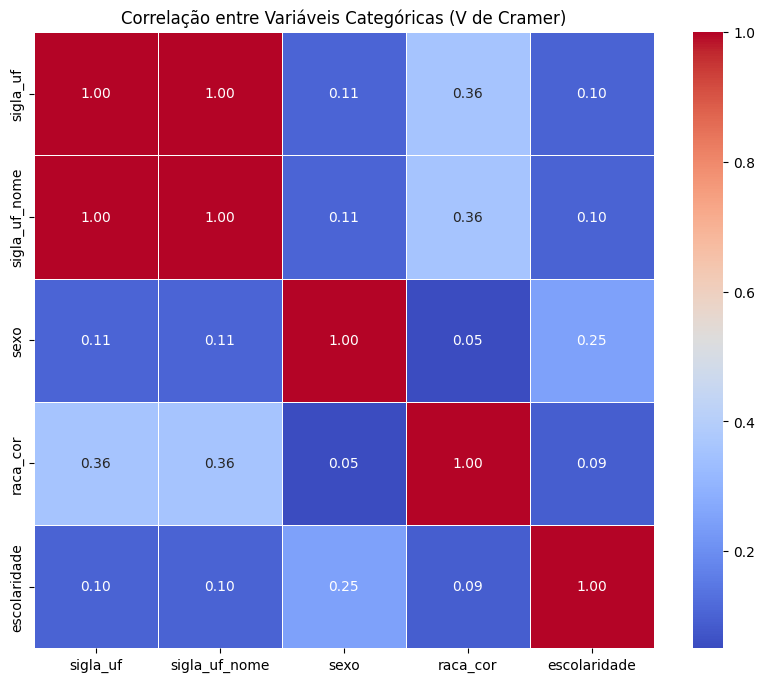

In [71]:
import numpy as np
from scipy.stats import chi2_contingency

# Função para calcular o V de Cramer
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Selecionar apenas colunas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns

# Criar matriz de correlação para variáveis categóricas
correlation_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            correlation_matrix.loc[col1, col2] = 1.0  # Correlação perfeita consigo mesma
        else:
            correlation_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Converter para float
correlation_matrix = correlation_matrix.astype(float)

# Plotar matriz de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlação entre Variáveis Categóricas (V de Cramer)")
plt.show()

In [72]:
import scipy.stats as stats

# Selecionar as colunas categóricas
categorical_columns = ['sigla_uf', 'acompanhamento', 'sexo', 'povo_comunidade', 'escolaridade', 'nome_municipio', 'faixa etária']

# Criar um dicionário para armazenar os resultados
anova_results = {}

# Aplicar o teste ANOVA para cada variável categórica
for col in categorical_columns:
    if col in df.columns:
        # Criar grupos de IMC para cada categoria da variável categórica
        groups = [df[df[col] == category]['imc'].dropna() for category in df[col].unique()]

        # Remover categorias que possuem menos de 2 grupos distintos
        groups = [group for group in groups if len(group) > 1]

        if len(groups) > 1:  # Apenas executa ANOVA se houver pelo menos dois grupos
            f_stat, p_value = stats.f_oneway(*groups)
            anova_results[col] = p_value

# Exibir os resultados ordenados por significância estatística
anova_results = dict(sorted(anova_results.items(), key=lambda x: x[1]))
print("Correlação entre variáveis categóricas e IMC (p-valores):")
for col, p_val in anova_results.items():
    print(f"{col}: {p_val:.5f}")

# Interpretação:
# - Quanto menor o p-valor, maior a correlação entre a variável categórica e o IMC.
# - Se p < 0.05, a variável tem uma relação estatisticamente significativa com o IMC

Correlação entre variáveis categóricas e IMC (p-valores):
escolaridade: 0.00442
sigla_uf: 0.02437
sexo: 0.02623


## <font color=green size=6>**Esclarecimentos e Requisitos do projeto**</font>

1. Este projeto precisa começar pela definição de um tema. Por exemplo: arboviroses no Brasil.


2. A partir do tema, a equipe deve identificar um banco de dados ou dataset, preferencialmente, utilizando dados reais.


3. Com base na relação entre o tema e os dados identificados, a equipe deve identificar um problema a ser solucionado. Por exemplo: identificar as principais condutas das pessoas que podem prevenir a piora de um quadro de arbovirose. É preciso que esse problema seja passível de solução por meio do banco de dados escolhido pela equipe.


4. A equipe deve pré-processar o banco de dados identificado.
- 4.1. Provavelmente, nem todas as colunas (variáveis / features) presentes no banco serão necessárias para a solução do problema que a equipe escolheu para lidar.
- 4.2 Da mesma forma, nem todas as linhas do banco (relacionadas a dados como os de participantes de uma pesquisa) podem ser necessárias. Por exemplo: algumas linhas podem ter muitos dados nulos, que pode ser útil simplesmente excluir. Outro exemplo: o estudo que a equipe escolheu envolve apenas a saúde da mulher, permitindo a exclusão dos dados dos homens.
- 4.3. Por fim, é possível que existam dados inconsistentes e que precisam ser corrigidos ou dados com texto e que devem ser transformados em números, se o que se espera é que sejam processados estatisticamente.


5. Com o banco de dados em condições de processamento, é necessário conduzir uma Análise Exploratória de Dados. Isso significa utilizar bibliotecas do python que permitiu calcular estatísticas descritivas.
- 5.1. Considere as seguintes estatísticas: medidas de tendência central (ex.: média), medidas de dispersão (ex.: desvio-padrão), medidas de contagem e proporção (ex.: frequência, percentual), medidas de associação (ex.: correlação de pearson).
- 5.2. Considere os seguintes gráficos: histograma, gráfico de barras, boxplot.
- 5.3. Você deve apresentar neste notebook 05 estatísticas descritivas e 05 gráficos relacionados ao banco de dados pré-processado e que ajudem a caracterizar os seus dados, te aproximando da solução do problema que a equipe selecionou.


6. Esta entrega deve ocorrer até o dia 12/12/2024.

*A título de informação, lembramos que a 2ª entrega deste projeto será um modelo de IA, que ajude a solucionar o problema que a equipe escolheu e a última entrega será um dashboard unindo as estatísticas da 1ª entrega com o modelo da 2ª entrega.*

# Trabalhos Futuros

---

Calcular / prever

pra dar entrada minha idade, meu município e ver se eu estou na média da minha cidade para minha idade

e tentar prever o IMC do futuro.


regressão usando o IMC como variável base

Usaremos regressão para que, a partir das informações (sexo,idade e localidade e IMC) do usuário nosso sistema perguntará para quanto tempo o usuário quer prever seu imc. O nosso sistema retornará o IMC previsto para aquela localidade, aquela idade e aquele gênero, e verifica a diferença de valores entre o IMC inserido pelo usuário e o IMC previsto pelo modelo








In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135000 entries, 0 to 134999
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   ano            135000 non-null  int64   
 1   sigla_uf       135000 non-null  object  
 2   sigla_uf_nome  135000 non-null  object  
 3   idade          135000 non-null  int64   
 4   sexo           135000 non-null  object  
 5   raca_cor       135000 non-null  object  
 6   escolaridade   135000 non-null  object  
 7   peso           135000 non-null  float64 
 8   altura         135000 non-null  float64 
 9   imc            135000 non-null  float64 
 10  faixa_etaria   135000 non-null  category
dtypes: category(1), float64(3), int64(2), object(5)
memory usage: 10.4+ MB


---

Após treinar o modelo, é importante validar sua performance com métricas adequadas (como RMSE, R², ou MAE) para garantir que o modelo esteja bem ajustado e generalizando bem para novos dados.

In [74]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = df[['idade', 'sexo', 'peso', 'altura']]  # Variáveis independentes
y = df['imc']  # Variável dependente

# convertendo variável categórica 'sexo' para numérica
X['sexo'] = LabelEncoder().fit_transform(X['sexo'])

<ipython-input-74-d5411f7e1b50>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [75]:
X

,idade,sexo,peso,altura
0,71,0,64.5,1.54
1,63,0,91.0,1.57
2,67,0,54.0,1.46
3,60,0,51.0,1.48
4,63,1,72.0,1.52
...,...,...,...,...
134995,53,0,76.4,1.56
134996,53,0,84.9,162.00
134997,53,1,68.0,164.00
134998,53,0,73.0,1.53


In [76]:
from sklearn.model_selection import train_test_split

# Normalizar os dados numéricos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [77]:
X_scaled

array([[ 2.53777476, -0.70308007,  0.14741476, -0.02461481],
       [ 2.13085372, -0.70308007,  0.36572666, -0.02460736],
       [ 2.33431424, -0.70308007,  0.06091383, -0.02463468],
       ...,
       [ 1.62220241,  1.42231312,  0.17624841,  0.01574239],
       [ 1.62220241, -0.70308007,  0.21743933, -0.02461729],
       [ 1.62220241, -0.70308007,  0.17789605,  0.01524557]])

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

results = {}

In [79]:
from sklearn.ensemble import RandomForestRegressor


# Criar e treinar o modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Fazer previsões
y_pred_rf = rf_model.predict(X_test)
results['Random Forest'] = {
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": mean_squared_error(y_test, y_pred_rf),
    "R²": r2_score(y_test, y_pred_rf)
}


In [80]:
from sklearn.linear_model import LinearRegression

# Criar e treinar o modelo de regressão linear
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Fazer previsões
y_pred_lr = lr_model.predict(X_test)

results['Regressão Linear'] = {
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": mean_squared_error(y_test, y_pred_lr),
    "R²": r2_score(y_test, y_pred_lr)
}

In [81]:
from sklearn.svm import SVR

# Criar e treinar o modelo de SVR
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Fazer previsões
y_pred_svr = svr_model.predict(X_test)

results['SVR'] = {
    "MAE": mean_absolute_error(y_test, y_pred_svr),
    "RMSE": mean_squared_error(y_test, y_pred_svr),
    "R²": r2_score(y_test, y_pred_svr)
}

In [82]:
from sklearn.ensemble import AdaBoostRegressor

# Criar o modelo AdaBoostRegressor com uma árvore de decisão como modelo base
ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)

# Treinar o modelo
ada_model.fit(X_train, y_train)

# Previsões
y_pred_ada = ada_model.predict(X_test)

results['Regressão Ada'] = {
    "MAE": mean_absolute_error(y_test, y_pred_ada),
    "RMSE": mean_squared_error(y_test, y_pred_ada),
    "R²": r2_score(y_test, y_pred_ada)
}

In [83]:
df_results = pd.DataFrame(results).T
print(df_results)


                         MAE          RMSE        R²
Random Forest      66.783370  3.117544e+07 -1.104995
Regressão Linear  140.444748  1.480052e+07  0.000655
SVR                54.413794  1.481336e+07 -0.000211
Regressão Ada      41.174050  4.743817e+06  0.679693


Melhorando o modelo random forest


In [84]:
df.sample(2)


,ano,sigla_uf,sigla_uf_nome,idade,sexo,raca_cor,escolaridade,peso,altura,imc,faixa_etaria
50674,2021,RR,Roraima,6,F,Parda,Pré-escola (exceto ca),18.75,114.00,13.85,0-18
6416,2015,RJ,Rio de Janeiro,54,F,Branca,Ensino fundamental 5ª a 8ª séries,76.50,1.56,31.43,41-60


###Melhoramos o modelo com a inserssão de mais duas variáveis: 'raca_cor' e 'escolaridade'

In [85]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = df[['idade', 'sexo', 'peso', 'altura', 'escolaridade', 'sigla_uf', 'raca_cor']]  # Variáveis independentes
y = df['imc']  # Variável dependente

# convertendo variável categórica 'sexo' para numérica
X['sexo'] = LabelEncoder().fit_transform(X['sexo'])
X['raca_cor'] = LabelEncoder().fit_transform(X['raca_cor'])
X['escolaridade'] = LabelEncoder().fit_transform(X['escolaridade'])
X['sigla_uf'] = LabelEncoder().fit_transform(X['sigla_uf'])

<ipython-input-85-de0da4c8f827>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-85-de0da4c8f827>:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-85-de0da4c8f827>:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-85-de0da4c

In [ ]:
# Normalizar os dados numéricos
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

In [86]:
X

,idade,sexo,peso,altura,escolaridade,sigla_uf,raca_cor
0,71,0,64.5,1.54,1,21,3
1,63,0,91.0,1.57,1,21,3
2,67,0,54.0,1.46,2,21,3
3,60,0,51.0,1.48,1,21,3
4,63,1,72.0,1.52,2,21,3
...,...,...,...,...,...,...,...
134995,53,0,76.4,1.56,1,17,1
134996,53,0,84.9,162.00,4,17,3
134997,53,1,68.0,164.00,4,17,1
134998,53,0,73.0,1.53,1,17,1


In [87]:
contagem_escolaridade = X['escolaridade'].value_counts()

print(contagem_escolaridade)

escolaridade
2     39193
1     25810
3     18834
4     14684
12    12002
5     11073
11     7552
13     1513
6      1182
10      967
8       869
7       742
9       383
0       196
Name: count, dtype: int64


In [88]:
# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}

In [89]:
# Criar e treinar o modelo Random Forest
rf_model_1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_1.fit(X_train, y_train)

# Fazer previsões
y_pred_rf = rf_model_1.predict(X_test)

results['Random Forest'] = {
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": mean_squared_error(y_test, y_pred_rf),
    "R²": r2_score(y_test, y_pred_rf)
}

In [90]:
from sklearn.ensemble import AdaBoostRegressor

# Criar o modelo AdaBoostRegressor com uma árvore de decisão como modelo base
ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)

# Treinar o modelo
ada_model.fit(X_train, y_train)

# Previsões
y_pred_ada = ada_model.predict(X_test)

results['Regressão Ada'] = {
    "MAE": mean_absolute_error(y_test, y_pred_ada),
    "RMSE": mean_squared_error(y_test, y_pred_ada),
    "R²": r2_score(y_test, y_pred_ada)
}

In [91]:
from sklearn.svm import SVR

# Criar e treinar o modelo de SVR
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Fazer previsões
y_pred_svr = svr_model.predict(X_test)

results['SVR'] = {
    "MAE": mean_absolute_error(y_test, y_pred_svr),
    "RMSE": mean_squared_error(y_test, y_pred_svr),
    "R²": r2_score(y_test, y_pred_svr)
}

KeyboardInterrupt: 

In [92]:
from sklearn.linear_model import LinearRegression

# Criar e treinar o modelo de regressão linear
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Fazer previsões
y_pred_lr = lr_model.predict(X_test)

results['Regressão Linear'] = {
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": mean_squared_error(y_test, y_pred_lr),
    "R²": r2_score(y_test, y_pred_lr)
}

In [93]:
df_results = pd.DataFrame(results).T
print(df_results)

                         MAE          RMSE         R²
Random Forest      80.046063  5.136118e+07  -2.467954
Regressão Ada     501.183285  2.440266e+08 -15.476904
Regressão Linear  163.760708  1.479332e+07   0.001141


Aplicando a coluna "sigla_uf"

In [94]:
df['sigla_uf'] = LabelEncoder().fit_transform(df['sigla_uf'])

X = df[['idade', 'sexo', 'peso', 'altura', 'escolaridade', 'sigla_uf', 'raca_cor']]
y = df['imc']

In [95]:
import joblib  # Para carregar o modelo treinado

In [96]:
rf_model = joblib.load("modelo_random_forest.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'modelo_random_forest.pkl'

In [97]:
def processar_dados(dados):
  dados ['sexo'] = LabelEncoder().fit_transform(X['sexo'])
  dados ['raca_cor'] = LabelEncoder().fit_transform(X['raca_cor'])
  dados ['escolaridade'] = LabelEncoder().fit_transform(X['escolaridade'])
  dados ['sigla_uf'] = LabelEncoder().fit_transform(X['sigla_uf'])
  # Normalizar os dados numéricos
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(dados)
  return X_scaled

In [98]:
def prever_imc(idade, sexo, peso, altura, escolaridade, estado, raca):
    # Criar um DataFrame com os inputs do usuário
    dados = pd.DataFrame([[idade, sexo, peso, altura, escolaridade, estado, raca]],
                         columns=["idade", "sexo", "peso", "altura", "escolaridade", "sigla_uf", "raça"])

    # Pré-processamento dos dados (exemplo: transformar categóricos em numéricos)
    dados = processar_dados(dados)  # Certifique-se de ter essa função implementada como no seu treinamento

    # Fazer a previsão
    imc_previsto = rf_model.predict(dados)

    return f"IMC Previsto: {imc_previsto[0]:.2f}"

In [99]:
df

,ano,sigla_uf,sigla_uf_nome,idade,sexo,raca_cor,escolaridade,peso,altura,imc,faixa_etaria
0,2013,21,Roraima,71,F,Parda,Classe alfabetizada - ca,64.5,1.54,27.20,>60
1,2012,21,Roraima,63,F,Parda,Classe alfabetizada - ca,91.0,1.57,36.92,>60
2,2012,21,Roraima,67,F,Parda,Creche,54.0,1.46,25.33,>60
3,2010,21,Roraima,60,F,Parda,Classe alfabetizada - ca,51.0,1.48,23.28,>60
4,2012,21,Roraima,63,M,Parda,Creche,72.0,1.52,31.16,>60
...,...,...,...,...,...,...,...,...,...,...,...
134995,2009,17,Paraná,53,F,Branca,Classe alfabetizada - ca,76.4,1.56,31.39,41-60
134996,2023,17,Paraná,53,F,Parda,Ensino fundamental 5ª a 8ª séries,84.9,162.00,32.35,41-60
134997,2021,17,Paraná,53,M,Branca,Ensino fundamental 5ª a 8ª séries,68.0,164.00,25.28,41-60
134998,2015,17,Paraná,53,F,Branca,Classe alfabetizada - ca,73.0,1.53,31.18,41-60


In [100]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [101]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Função para calcular o IMC
def calcular_imc(peso, altura):
    altura_metros = altura / 100  # Convertendo cm para metros
    return peso / (altura_metros ** 2)

# Criando um dataset fictício para treinar o modelo
data = df

In [102]:
df

,ano,sigla_uf,sigla_uf_nome,idade,sexo,raca_cor,escolaridade,peso,altura,imc,faixa_etaria
0,2013,21,Roraima,71,F,Parda,Classe alfabetizada - ca,64.5,1.54,27.20,>60
1,2012,21,Roraima,63,F,Parda,Classe alfabetizada - ca,91.0,1.57,36.92,>60
2,2012,21,Roraima,67,F,Parda,Creche,54.0,1.46,25.33,>60
3,2010,21,Roraima,60,F,Parda,Classe alfabetizada - ca,51.0,1.48,23.28,>60
4,2012,21,Roraima,63,M,Parda,Creche,72.0,1.52,31.16,>60
...,...,...,...,...,...,...,...,...,...,...,...
134995,2009,17,Paraná,53,F,Branca,Classe alfabetizada - ca,76.4,1.56,31.39,41-60
134996,2023,17,Paraná,53,F,Parda,Ensino fundamental 5ª a 8ª séries,84.9,162.00,32.35,41-60
134997,2021,17,Paraná,53,M,Branca,Ensino fundamental 5ª a 8ª séries,68.0,164.00,25.28,41-60
134998,2015,17,Paraná,53,F,Branca,Classe alfabetizada - ca,73.0,1.53,31.18,41-60


In [117]:
# Criar um dicionário de mapeamento para a coluna escolaridade, visando que ela fique mais "Limpa"
mapeamento_escolaridade = {
    "Classe alfabetizada - ca": "Alfabetização",
    "Alfabetização para adultos (mobral, etc)": "Alfabetização",
    "Creche": "Alfabetização",
    "Pré-escola (exceto ca)": "Alfabetização",

    "Ensino fundamental 1ª a 4ª séries": "Fundamental",
    "Ensino fundamental 5ª a 8ª séries": "Fundamental",
    "Ensino fundamental completo": "Fundamental",
    "Ensino fundamental especial": "Fundamental",
    "Ensino fundamental eja - séries iniciais (supletivo 1ª a 4ª)": "Fundamental",
    "Ensino fundamental eja - séries iniciais (supletivo 5ª a 8ª)": "Fundamental",

    "Ensino médio, médio2º ciclo (científico,técnico e etc)": "Médio",
    "Ensino médio especial": "Médio",
    "Ensino médio eja(supletivo)": "Médio",

    "Superior, aperfeiçoamento, especialização, mestrado, doutorado": "Superior"
}
# Aplicar a substituição
df["escolaridade"] = df["escolaridade"].replace(mapeamento_escolaridade)

# Verificar as novas categorias
df["escolaridade"].value_counts()

,count
escolaridade,
Alfabetização,65199
Ensino Fundamental,47384
Educação Infantil,12002
Ensino Médio,8902
Ensino Superior,1513


In [118]:
# Função para calcular o IMC
def calcular_imc(peso, altura):
    altura_metros = altura / 100  # Convertendo cm para metros
    return peso / (altura_metros ** 2)

# Dicionários para mapeamento
map_sexo = {'Feminino': 0, 'Masculino': 1}
map_escolaridade = {'Alfabetização': 0, 'Fundamental': 1, 'Médio': 2, 'Superior': 3}
map_raca_cor = {'Parda': 0, 'Branca': 1, 'Preta': 2, 'Amarela': 3, 'Indígena': 4}

map_sigla_uf = {
    'RR': 0, 'RJ': 1, 'SP': 2, 'MG': 3, 'PA': 4, 'MS': 5, 'SC': 6, 'BA': 7, 'RS': 8, 'CE': 9,
    'MT': 10, 'MA': 11, 'ES': 12, 'PB': 13, 'RO': 14, 'GO': 15, 'AL': 16, 'TO': 17, 'PE': 18,
    'AM': 19, 'AC': 20, 'RN': 21, 'PI': 22, 'AP': 23, 'DF': 24, 'SE': 25, 'PR': 26
}

# Função para entrada de dados do usuário e previsão do IMC
def prever_imc_usuario():
    idade = int(input("Digite sua idade: "))
    sexo = input("Digite seu sexo (Masculino/Feminino): ")
    peso = float(input("Digite seu peso em kg: "))
    altura = float(input("Digite sua altura em cm: "))
    escolaridade = input("Digite seu nível de escolaridade (Fundamental/Médio/Superior): ")
    sigla_uf = input("Digite seu estado (sigla UF, ex: MA): ").upper()
    raca_cor = input("Digite sua raça/cor (Branca/Preta/Parda/Amarela/Indígena): ")

    # Converte as entradas do usuário para os valores numéricos do modelo
    sexo_codificado = map_sexo.get(sexo, -1)
    escolaridade_codificada = map_escolaridade.get(escolaridade, -1)
    sigla_uf_codificada = map_sigla_uf.get(sigla_uf, -1)
    raca_cor_codificada = map_raca_cor.get(raca_cor, -1)

    print(escolaridade_codificada)
    print(raca_cor_codificada)



    if -1 in [sexo_codificado, escolaridade_codificada, sigla_uf_codificada, raca_cor_codificada]:
        print("Algum dado foi inserido incorretamente. Tente novamente.")
        return

    # Calcular o IMC real
    imc_real = calcular_imc(peso, altura)

    # Criar array para previsão
    entrada = np.array([[idade, sexo_codificado, peso, altura, escolaridade_codificada, sigla_uf_codificada, raca_cor_codificada]])
    print(entrada)
    # entrada = scaler.transform(entrada)
    print(entrada)
    # Fazer previsão do modelo
    imc_predito = rf_model_1.predict(entrada)[0]

    print(f"\nIMC Real calculado: {imc_real:.2f}")
    print(f"IMC Previsto pelo modelo: {imc_predito:.2f}")

# Chamar a função para entrada do usuário e previsão
prever_imc_usuario()

Digite sua idade: 20
Digite seu sexo (Masculino/Feminino): Masculino
Digite seu peso em kg: 80
Digite sua altura em cm: 180
Digite seu nível de escolaridade (Fundamental/Médio/Superior): Superior
Digite seu estado (sigla UF, ex: MA): MT
Digite sua raça/cor (Branca/Preta/Parda/Amarela/Indígena): Parda
3
0
[[ 20.   1.  80. 180.   3.  10.   0.]]
[[ 20.   1.  80. 180.   3.  10.   0.]]

IMC Real calculado: 24.69
IMC Previsto pelo modelo: 24.59


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names



In [119]:
df.sample(5)

,ano,sigla_uf,sigla_uf_nome,idade,sexo,raca_cor,escolaridade,peso,altura,imc,faixa_etaria
3445,2014,0,Acre,55,M,Parda,Alfabetização,62.4,1.60,24.38,41-60
109764,2012,20,Rondônia,29,M,Parda,Alfabetização,72.0,1.72,24.34,26-40
50012,2009,13,Pará,5,M,Parda,Educação Infantil,19.0,108.00,16.29,0-18
90276,2016,20,Rondônia,19,F,Parda,Alfabetização,67.0,150.00,29.78,19-25
96412,2020,24,Sergipe,22,F,Parda,Ensino Fundamental,63.5,162.00,24.20,19-25


In [120]:
X

,idade,sexo,peso,altura,escolaridade,sigla_uf,raca_cor
0,71,F,64.5,1.54,Classe alfabetizada - ca,21,Parda
1,63,F,91.0,1.57,Classe alfabetizada - ca,21,Parda
2,67,F,54.0,1.46,Creche,21,Parda
3,60,F,51.0,1.48,Classe alfabetizada - ca,21,Parda
4,63,M,72.0,1.52,Creche,21,Parda
...,...,...,...,...,...,...,...
134995,53,F,76.4,1.56,Classe alfabetizada - ca,17,Branca
134996,53,F,84.9,162.00,Ensino fundamental 5ª a 8ª séries,17,Parda
134997,53,M,68.0,164.00,Ensino fundamental 5ª a 8ª séries,17,Branca
134998,53,F,73.0,1.53,Classe alfabetizada - ca,17,Branca


In [ ]:
contagem_uf = df['sigla_uf'].value_counts()

print(contagem_uf)

sigla_uf
MT    3060
SC    2282
AM    1592
AL     591
TO     580
GO     490
MS     328
AC     295
AP     217
MA     206
RR     175
SE     117
ES      52
DF      12
RO       3
Name: count, dtype: int64


In [ ]:
contagem_uf = df['sigla_uf'].value_counts()
contagem_cor = df['raca_cor'].value_counts()

print(contagem_uf)
print(contagem_cor)

sigla_uf
9     3060
12    2282
2     1592
1      591
14     580
6      490
8      328
0      295
3      217
7      206
11     175
13     117
5       52
4       12
10       3
Name: count, dtype: int64
raca_cor
Parda             5147
Branca            3699
Preta              348
Amarela            336
Indigena           302
Sem informacao     168
Name: count, dtype: int64


In [126]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.3 MB/s eta 0:00:00


In [129]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Função para calcular o IMC
def calcular_imc(peso, altura):
    altura_metros = altura / 100  # Convertendo cm para metros
    return peso / (altura_metros ** 2)

# Dicionários para mapeamento
map_sexo = {'Feminino': 0, 'Masculino': 1}
map_escolaridade = {'Alfabetização': 0, 'Fundamental': 1, 'Médio': 2, 'Superior': 3}
map_raca_cor = {'Parda': 0, 'Branca': 1, 'Preta': 2, 'Amarela': 3, 'Indígena': 4}

map_sigla_uf = {
    'RR': 0, 'RJ': 1, 'SP': 2, 'MG': 3, 'PA': 4, 'MS': 5, 'SC': 6, 'BA': 7, 'RS': 8, 'CE': 9,
    'MT': 10, 'MA': 11, 'ES': 12, 'PB': 13, 'RO': 14, 'GO': 15, 'AL': 16, 'TO': 17, 'PE': 18,
    'AM': 19, 'AC': 20, 'RN': 21, 'PI': 22, 'AP': 23, 'DF': 24, 'SE': 25, 'PR': 26
}

# Criando widgets para entrada de dados
idade = widgets.IntText(description="Idade:", value=25)
sexo = widgets.Dropdown(description="Sexo:", options=list(map_sexo.keys()))
peso = widgets.FloatText(description="Peso (kg):", value=70.0)
altura = widgets.FloatText(description="Altura (cm):", value=170.0)
escolaridade = widgets.Dropdown(description="Escolaridade:", options=list(map_escolaridade.keys()))
sigla_uf = widgets.Dropdown(description="Estado:", options=list(map_sigla_uf.keys()))
raca_cor = widgets.Dropdown(description="Raça/Cor:", options=list(map_raca_cor.keys()))

# Exibir os widgets
display(idade, sexo, peso, altura, escolaridade, sigla_uf, raca_cor)

# Função para previsão do IMC
def prever_imc_usuario(b):
    # Coletar valores selecionados
    idade_val = idade.value
    sexo_val = map_sexo[sexo.value]
    peso_val = peso.value
    altura_val = altura.value
    escolaridade_val = map_escolaridade[escolaridade.value]
    sigla_uf_val = map_sigla_uf[sigla_uf.value]
    raca_cor_val = map_raca_cor[raca_cor.value]

    # Calcular IMC real
    imc_real = calcular_imc(peso_val, altura_val)

    # Criar array para previsão
    entrada = np.array([[idade_val, sexo_val, peso_val, altura_val, escolaridade_val, sigla_uf_val, raca_cor_val]])

    print("\n📊 **Dados de Entrada:**")
    print(entrada)

    # Fazer previsão do modelo (descomente quando estiver com o modelo treinado)
    # entrada = scaler.transform(entrada)
    # imc_predito = rf_model_1.predict(entrada)[0]

    # Simulação de um IMC previsto (substituir pelo modelo real)
    imc_predito = imc_real + np.random.uniform(-1, 1)

    print(f"\n✅ **IMC Real calculado:** {imc_real:.2f}")
    print(f"🔮 **IMC Previsto pelo modelo:** {imc_predito:.2f}")

# Botão para rodar a previsão
botao = widgets.Button(description="Calcular IMC")
botao.on_click(prever_imc_usuario)
display(botao)


IntText(value=25, description='Idade:')

Dropdown(description='Sexo:', options=('Feminino', 'Masculino'), value='Feminino')

FloatText(value=70.0, description='Peso (kg):')

FloatText(value=170.0, description='Altura (cm):')

Dropdown(description='Escolaridade:', options=('Alfabetização', 'Fundamental', 'Médio', 'Superior'), value='Al…

Dropdown(description='Estado:', options=('RR', 'RJ', 'SP', 'MG', 'PA', 'MS', 'SC', 'BA', 'RS', 'CE', 'MT', 'MA…

Dropdown(description='Raça/Cor:', options=('Parda', 'Branca', 'Preta', 'Amarela', 'Indígena'), value='Parda')

Button(description='Calcular IMC', style=ButtonStyle())


📊 **Dados de Entrada:**
[[ 25.   0.  70. 170.   0.   0.   0.]]

✅ **IMC Real calculado:** 24.22
🔮 **IMC Previsto pelo modelo:** 23.34


In [131]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Função para calcular o IMC
def calcular_imc(peso, altura):
    altura_metros = altura / 100  # Convertendo cm para metros
    return peso / (altura_metros ** 2)

# Dicionários para mapeamento
map_sexo = {'Feminino': 0, 'Masculino': 1}
map_escolaridade = {'Fundamental': 1, 'Médio': 2, 'Superior': 3}
map_raca_cor = {'Parda': 0, 'Branca': 1, 'Preta': 2, 'Amarela': 3, 'Indígena': 4}

map_sigla_uf = {
    'RR': 0, 'RJ': 1, 'SP': 2, 'MG': 3, 'PA': 4, 'MS': 5, 'SC': 6, 'BA': 7, 'RS': 8, 'CE': 9,
    'MT': 10, 'MA': 11, 'ES': 12, 'PB': 13, 'RO': 14, 'GO': 15, 'AL': 16, 'TO': 17, 'PE': 18,
    'AM': 19, 'AC': 20, 'RN': 21, 'PI': 22, 'AP': 23, 'DF': 24, 'SE': 25, 'PR': 26
}

# Criando widgets para entrada de dados
idade = widgets.IntText(description="Idade:", value=20)
sexo = widgets.Dropdown(description="Sexo:", options=list(map_sexo.keys()))
peso = widgets.FloatText(description="Peso (kg):", value=70.0)
altura = widgets.FloatText(description="Altura (cm):", value=170.0)
escolaridade = widgets.Dropdown(description="Escolaridade:", options=list(map_escolaridade.keys()))
sigla_uf = widgets.Dropdown(description="Estado:", options=list(map_sigla_uf.keys()))
raca_cor = widgets.Dropdown(description="Raça/Cor:", options=list(map_raca_cor.keys()))
anos_futuro = widgets.IntText(description="Previsão para (anos):", value=5)

# Exibir os widgets
display(idade, sexo, peso, altura, escolaridade, sigla_uf, raca_cor, anos_futuro)

# Simulação de base de dados de IMC por idade (substituir por base real)
dados_imc = {
    20: np.random.normal(22, 2, 1000),  # Média de 22, desvio padrão de 2
    25: np.random.normal(24, 2.5, 1000),  # Média de 24, desvio padrão de 2.5
    30: np.random.normal(25, 3, 1000),  # Média de 25, desvio padrão de 3
}

# Função para previsão do IMC
def prever_imc_usuario(b):
    # Coletar valores selecionados
    idade_val = idade.value
    sexo_val = map_sexo[sexo.value]
    peso_val = peso.value
    altura_val = altura.value
    escolaridade_val = map_escolaridade[escolaridade.value]
    sigla_uf_val = map_sigla_uf[sigla_uf.value]
    raca_cor_val = map_raca_cor[raca_cor.value]
    idade_futura = idade_val + anos_futuro.value

    # Calcular IMC real
    imc_real = calcular_imc(peso_val, altura_val)

    print(f"Idade Atual: {idade_val} anos | IMC Atual: {imc_real:.2f}")
    print(f"🔮 **IMC Previsto para {idade_val} anos:** {imc_previsto:.2f}")

    print(f"Previsão para: {idade_futura} anos")

    # Verificar se temos dados para a idade futura
    if idade_val in dados_imc and idade_futura in dados_imc:
        # Calcular média e desvio padrão do IMC da idade futura
        media_idade_atual = np.mean(dados_imc[idade_val])
        desvio_padrao_idade_atual = np.std(dados_imc[idade_val])
        media_idade_futura = np.mean(dados_imc[idade_futura])
        desvio_padrao_idade_futura = np.std(dados_imc[idade_futura])

        # Ajustar o IMC conforme o desvio padrão da nova idade
        imc_previsto = imc_real + (media_idade_futura - media_idade_atual) + np.random.uniform(-desvio_padrao_idade_futura, desvio_padrao_idade_futura)

        print(f"\n✅ **IMC Real calculado:** {imc_real:.2f}")
        print(f"🔮 **IMC Previsto para {idade_futura} anos:** {imc_previsto:.2f}")
    else:
        print("\n❌ Não há dados suficientes para prever essa idade.")

# Botão para rodar a previsão
botao = widgets.Button(description="Calcular IMC Futuro")
botao.on_click(prever_imc_usuario)
display(botao)






# 20 anos REAL
# -
# 20 anos PREVISÃO
# = Desvio padrão


# 25 anos previsão + Desvio Padrão
# = IMC PREVISTO PRA 25 anos












IntText(value=20, description='Idade:')

Dropdown(description='Sexo:', options=('Feminino', 'Masculino'), value='Feminino')

FloatText(value=70.0, description='Peso (kg):')

FloatText(value=170.0, description='Altura (cm):')

Dropdown(description='Escolaridade:', options=('Fundamental', 'Médio', 'Superior'), value='Fundamental')

...

Dropdown(description='Raça/Cor:', options=('Parda', 'Branca', 'Preta', 'Amarela', 'Indígena'), value='Parda')

IntText(value=5, description='Previsão para (anos):')

Button(description='Calcular IMC Futuro', style=ButtonStyle())

Idade Atual: 20 anos | IMC Atual: 24.69


UnboundLocalError: cannot access local variable 'imc_previsto' where it is not associated with a value

In [133]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# Função para calcular o IMC
def calcular_imc(peso, altura):
    altura_metros = altura / 100  # Convertendo cm para metros
    return peso / (altura_metros ** 2)

# Dicionários para mapeamento
map_sexo = {'Feminino': 0, 'Masculino': 1}
map_escolaridade = {'Fundamental': 1, 'Médio': 2, 'Superior': 3}
map_raca_cor = {'Parda': 0, 'Branca': 1, 'Preta': 2, 'Amarela': 3, 'Indígena': 4}
map_sigla_uf = {
    'RR': 0, 'RJ': 1, 'SP': 2, 'MG': 3, 'PA': 4, 'MS': 5, 'SC': 6, 'BA': 7, 'RS': 8, 'CE': 9,
    'MT': 10, 'MA': 11, 'ES': 12, 'PB': 13, 'RO': 14, 'GO': 15, 'AL': 16, 'TO': 17, 'PE': 18,
    'AM': 19, 'AC': 20, 'RN': 21, 'PI': 22, 'AP': 23, 'DF': 24, 'SE': 25, 'PR': 26
}

# Criando widgets para entrada de dados
idade = widgets.IntText(description="Idade:", value=20)
sexo = widgets.Dropdown(description="Sexo:", options=list(map_sexo.keys()))
peso = widgets.FloatText(description="Peso (kg):", value=70.0)
altura = widgets.FloatText(description="Altura (cm):", value=170.0)
escolaridade = widgets.Dropdown(description="Escolaridade:", options=list(map_escolaridade.keys()))
sigla_uf = widgets.Dropdown(description="Estado:", options=list(map_sigla_uf.keys()))
raca_cor = widgets.Dropdown(description="Raça/Cor:", options=list(map_raca_cor.keys()))
anos_futuro = widgets.IntText(description="Previsão para (anos):", value=5)

# Exibir os widgets
display(idade, sexo, peso, altura, escolaridade, sigla_uf, raca_cor, anos_futuro)

# Simulação de base de dados de IMC por idade (substituir por base real)
dados_imc = {
    20: np.random.normal(22, 2, 1000),  # Média de 22, desvio padrão de 2
    25: np.random.normal(24, 2.5, 1000),  # Média de 24, desvio padrão de 2.5
    30: np.random.normal(25, 3, 1000),  # Média de 25, desvio padrão de 3
}

# Função para previsão do IMC
def prever_imc_usuario(b):
    # Coletar valores selecionados
    idade_val = idade.value
    peso_val = peso.value
    altura_val = altura.value
    idade_futura = idade_val + anos_futuro.value

    # Calcular IMC real
    imc_real = calcular_imc(peso_val, altura_val)

    print(f"\n📌 **Idade Atual: {idade_val} anos**")
    print(f"✅ **IMC Real calculado:** {imc_real:.2f}")

    # Verificar se temos dados para a idade atual e futura
    if idade_val in dados_imc and idade_futura in dados_imc:
        # Calcular média e desvio padrão do IMC da idade atual
        media_idade_atual = np.mean(dados_imc[idade_val])
        desvio_padrao_idade_atual = np.std(dados_imc[idade_val])

        # Exibir o IMC esperado para a idade atual com base nos dados
        print(f"🔮 **IMC Esperado para {idade_val} anos:** {media_idade_atual:.2f}")

        # Calcular média e desvio padrão do IMC da idade futura
        media_idade_futura = np.mean(dados_imc[idade_futura])
        desvio_padrao_idade_futura = np.std(dados_imc[idade_futura])

        # IMC previsto para a idade futura
        imc_previsto = media_idade_futura + desvio_padrao_idade_atual

        print(f"\n📌 **Previsão para {idade_futura} anos**")
        print(f"🔮 **IMC Previsto:** {imc_previsto:.2f}")
    else:
        print("\n❌ Não há dados suficientes para prever essa idade.")

# Botão para rodar a previsão
botao = widgets.Button(description="Calcular IMC Futuro")
botao.on_click(prever_imc_usuario)
display(botao)

IntText(value=20, description='Idade:')

Dropdown(description='Sexo:', options=('Feminino', 'Masculino'), value='Feminino')

FloatText(value=70.0, description='Peso (kg):')

FloatText(value=170.0, description='Altura (cm):')

Dropdown(description='Escolaridade:', options=('Fundamental', 'Médio', 'Superior'), value='Fundamental')

Dropdown(description='Estado:', options=('RR', 'RJ', 'SP', 'MG', 'PA', 'MS', 'SC', 'BA', 'RS', 'CE', 'MT', 'MA…

Dropdown(description='Raça/Cor:', options=('Parda', 'Branca', 'Preta', 'Amarela', 'Indígena'), value='Parda')

IntText(value=5, description='Previsão para (anos):')

Button(description='Calcular IMC Futuro', style=ButtonStyle())


📌 **Idade Atual: 20 anos**
✅ **IMC Real calculado:** 24.69
🔮 **IMC Esperado para 20 anos:** 22.01

📌 **Previsão para 25 anos**
🔮 **IMC Previsto:** 25.92
